# Лабораторная работа 10

Тема: **Рекуррентные сети (LSTM/GRU) для классификации текстов в PyTorch**  
Цель: реализовать полный цикл решения задачи бинарной классификации текстов с помощью LSTM‑модели: от токенизации и построения словаря до обучения, валидации и анализа ошибок.

> Этот ноутбук оформлен как практическое задание.  
> Код даёт каркас, но основная часть баллов — за ваши собственные эксперименты и ваши пояснения.  
> Если вы попытаетесь автоматически сгенерировать весь текст отчёта, это будет заметно по стилю и несоответствию реальным графикам и числам.


## 1. Ваше исходное понимание задачи (обязательная текстовая часть)

Перед запуском кода зафиксируйте свои текущие представления (6–10 предложений):

1. Чем классификация текстов отличается от задач на изображения и табличные данные, с которыми вы уже работали.  
2. Зачем в текстовых задачах использовать рекуррентные сети (LSTM/GRU), а не просто среднее эмбеддингов слов с подачей в MLP.  
3. Как вы ожидаете, что **длина** текста и **порядок слов** повлияют на качество модели.

Пишите на своём языке, без попытки сделать "идеальное определение".


In [ ]:
intro_text = """Я понимаю задачу классификации текстов как попытку научить модель
определять смысл текста и относить его к нужному классу. В отличие от
изображений, текст состоит из последовательности слов, где важен порядок,
контекст и длина предложения. В табличных данных признаки обычно уже
подготовлены и имеют фиксированный размер, а в текстах сначала нужно
преобразовать слова в числовой вид. Также разные тексты могут иметь разную
длину, что усложняет обработку данных.

Я думаю, что рекуррентные сети LSTM и GRU хорошо подходят для текстов,
потому что они умеют учитывать последовательность слов и сохранять информацию
о предыдущих частях предложения. Если просто усреднить эмбеддинги слов и подать
их в MLP, то модель потеряет порядок слов и часть смысла текста. Например,
фразы с одинаковыми словами, но в разном порядке, могут иметь разный смысл.

Мне кажется, что длина текста тоже влияет на качество модели. Короткие тексты
могут содержать недостаточно информации, а длинные могут усложнять обучение
и приводить к потере важных зависимостей. Порядок слов особенно важен в задачах,
где смысл сильно меняется из-за контекста или отрицаний."""
print(intro_text)

## 2. Импорт библиотек и настройка среды

Загрузим необходимые библиотеки, зафиксируем зерно случайности и определим устройство (`cpu` или `cuda`).


In [1]:
import re
import random
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

MY_SEED = 13
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 13


## 3. Пример простого текстового датасета

Для примера используем небольшой игрушечный датасет коротких предложений на английском с метками `0/1` (негатив/позитив).  
В **своей** лабораторной вы должны будете взять более содержательный и шумный датасет (реальные отзывы, комментарии и т.п.) - выберите какой-нибудь объект (фильм на кинопоиске, товар на озоне/вб, заведение на яндекс картах), скопируйте о нем отзывы, переведите на английский, раскидайте по  двум классам. Свой датасет соберите в отдельной новой ячейке.


In [3]:
positive_sentences = [
    "I really liked this movie",
    "This film was great and inspiring",
    "What a fantastic experience",
    "I enjoyed every minute of it",
    "The actors did an amazing job",
    "Brilliant story and good pacing",
    "I would definitely watch it again",
    "It was funny and heartwarming",
    "A very beautiful and touching film",
    "Absolutely loved the characters"
]

negative_sentences = [
    "I really hated this movie",
    "This film was boring and slow",
    "What a terrible experience",
    "I regretted every minute of it",
    "The actors did a very bad job",
    "Awful story and strange pacing",
    "I would never watch it again",
    "It was dull and annoying",
    "A very ugly and pointless film",
    "Absolutely disliked the characters"
]

texts = positive_sentences + negative_sentences
labels = [1] * len(positive_sentences) + [0] * len(negative_sentences)

df = pd.DataFrame({"text": texts, "label": labels})
df = df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(df.head())
print("Размер датасета:", df.shape)
print("Распределение классов:\n", df["label"].value_counts())

                                 text  label
0       This film was boring and slow      0
1          What a terrible experience      0
2           I really liked this movie      1
3   This film was great and inspiring      1
4  A very beautiful and touching film      1
Размер датасета: (20, 2)
Распределение классов:
 label
0    10
1    10
Name: count, dtype: int64


In [4]:
positive_sentences = [
    "The drip bag does not let water pass properly, so the coffee brews very slowly and gets cold. Some liquid stays inside the bag. In the end I had to pour it into my own filter, even though I wanted ready-to-use drip coffee. The taste of the coffee is divine, so I still give it 5.",
    "Worth the money. We did not even notice that it was decaf. Now we want to order a bigger pack in beans. We decided to switch to decaf coffee because we take vitamins and life without coffee is not tasty.",
    "I have tried different brands, but this one is just amazing.",
    "With milk it is perfect. Thank you.",
    "Tasty coffee, fast delivery, reliable packaging.",
    "The best drip coffee. It can even be enjoyed without milk or cream.",
    "Aromatic and delicious coffee.",
    "My favorite drip coffee. Very aromatic, the whole kitchen smells like coffee after opening the packet.",
    "This is one of the most delicious coffees I have ever tried.",
    "The coffee is fresh, not sour, and strong enough. I liked the taste.",
    "Compared to grain coffee it cannot be the same, but among drip coffees it is one of the best."
]

negative_sentences = [
    "Not for me. I usually like Tasty Coffee drips, but I bought this because of the peanut flavor in the description and I could not drink it. It tasted very sour.",
    "I bought it for a trip. For me and my daughter it was too weak and tasteless. Just a reminder that everyone has different tastes.",
    "Honestly, the price seems too high. There are much tastier and cheaper coffees.",
    "Fast brew, good packaging, but there is almost no coffee taste, just a weak color.",
    "I have bought this coffee before, but this time it had no taste and no smell.",
    "The taste is like cheap coffee.",
    "Terrible taste. The whole kitchen smelled burnt, and the coffee tasted sour and over-roasted. Clearly defective. I threw everything away.",
    "Awful taste.",
    "Completely tasteless. I used two bags and still there was no flavor.",
    "The coffee box arrived without any packaging and was open. Terrible attitude toward customers.",
    "The production date was disappointing. The coffee was already 5 months old."
]

texts = positive_sentences + negative_sentences
labels = [1] * len(positive_sentences) + [0] * len(negative_sentences)

df = pd.DataFrame({"text": texts, "label": labels})
df = df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(df.head())
print("Размер датасета:", df.shape)
print("Распределение классов:\n", df["label"].value_counts())

                                                text  label
0  Not for me. I usually like Tasty Coffee drips,...      0
1  Fast brew, good packaging, but there is almost...      0
2  The drip bag does not let water pass properly,...      1
3  Worth the money. We did not even notice that i...      1
4  This is one of the most delicious coffees I ha...      1
Размер датасета: (22, 2)
Распределение классов:
 label
0    11
1    11
Name: count, dtype: int64


### Ваши замечания по датасету (обязательная мини‑секция)

Опишите (3–5 предложений):
- насколько базовый набор похож/не похож на реальные отзывы;  
- какие особенности реальных текстов в нем отсутствуют (длина, сленг, опечатки, смешение языков и т.п.);
- как эти отличия могут повлиять на результаты модели.


In [5]:
data_comment = """Этот датасет состоит из реальных отзывов с маркетплейса Ozon,
поэтому он уже отражает реальные пользовательские формулировки и реальные
ситуации использования товара. В текстах встречаются живые эмоции, сравнения,
оценка вкуса, качества и доставки, а также естественные для отзывов конструкции.

При этом набор всё ещё относительно небольшой и частично отфильтрованный, поэтому
в нём мало ярко выраженного “шума” в виде опечаток, эмодзи, сильного сленга или
многозначных противоречивых оценок. Также тексты в основном посвящены одной теме
(кофе), что упрощает задачу классификации.

Из-за этого модель может показывать более стабильные и высокие результаты, чем
на полном массиве данных с маркетплейса. В реальных условиях, где отзывы гораздо
разнообразнее и неоднозначнее, качество классификации может быть ниже и потребует
более сложной предобработки и большего объема данных."""
print(data_comment)

Этот датасет состоит из реальных отзывов с маркетплейса Ozon,
поэтому он уже отражает реальные пользовательские формулировки и реальные
ситуации использования товара. В текстах встречаются живые эмоции, сравнения,
оценка вкуса, качества и доставки, а также естественные для отзывов конструкции.

При этом набор всё ещё относительно небольшой и частично отфильтрованный, поэтому
в нём мало ярко выраженного “шума” в виде опечаток, эмодзи, сильного сленга или
многозначных противоречивых оценок. Также тексты в основном посвящены одной теме
(кофе), что упрощает задачу классификации.

Из-за этого модель может показывать более стабильные и высокие результаты, чем
на полном массиве данных с маркетплейса. В реальных условиях, где отзывы гораздо
разнообразнее и неоднозначнее, качество классификации может быть ниже и потребует
более сложной предобработки и большего объема данных.


## 4. Токенизация, словарь и паддинг

Сделаем простую токенизацию:
- приведём текст к нижнему регистру;
- удалим лишние символы;
- разобьём строку на токены по пробелам.

Затем построим словарь и приведём все последовательности к одинаковой длине `max_len` с помощью паддинга.


In [6]:
def simple_tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    return tokens

df["tokens"] = df["text"].apply(simple_tokenize)
print(df[["text", "tokens"]].head())

                                                text  \
0  Not for me. I usually like Tasty Coffee drips,...   
1  Fast brew, good packaging, but there is almost...   
2  The drip bag does not let water pass properly,...   
3  Worth the money. We did not even notice that i...   
4  This is one of the most delicious coffees I ha...   

                                              tokens  
0  [not, for, me, i, usually, like, tasty, coffee...  
1  [fast, brew, good, packaging, but, there, is, ...  
2  [the, drip, bag, does, not, let, water, pass, ...  
3  [worth, the, money, we, did, not, even, notice...  
4  [this, is, one, of, the, most, delicious, coff...  


In [7]:
# Подсчёт частот слов и построение словаря
word_counts = {}
for tokens in df["tokens"]:
    for w in tokens:
        word_counts[w] = word_counts.get(w, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: -x[1])

word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in sorted_words:
    word2idx[w] = len(word2idx)

idx2word = {idx: w for w, idx in word2idx.items()}

print("Размер словаря:", len(word2idx))
print("Первые элементы словаря:", list(word2idx.items())[:10])

Размер словаря: 179
Первые элементы словаря: [('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('coffee', 3), ('i', 4), ('and', 5), ('it', 6), ('is', 7), ('taste', 8), ('not', 9)]


In [8]:
def encode_tokens(tokens, word2idx):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

df["encoded"] = df["tokens"].apply(lambda t: encode_tokens(t, word2idx))
print(df[["tokens", "encoded"]].head())

lengths = df["encoded"].apply(len)
print("Мин и макс длины последовательностей:", lengths.min(), lengths.max())
max_len = int(lengths.max())  # для примера берём максимум
print("max_len =", max_len)

                                              tokens  \
0  [not, for, me, i, usually, like, tasty, coffee...   
1  [fast, brew, good, packaging, but, there, is, ...   
2  [the, drip, bag, does, not, let, water, pass, ...   
3  [worth, the, money, we, did, not, even, notice...   
4  [this, is, one, of, the, most, delicious, coff...   

                                             encoded  
0  [9, 19, 35, 4, 59, 20, 21, 3, 60, 11, 4, 22, 1...  
1  [39, 65, 66, 26, 11, 27, 7, 67, 16, 3, 8, 28, ...  
2  [2, 13, 41, 69, 9, 70, 71, 72, 73, 42, 2, 3, 7...  
3  [92, 2, 93, 18, 94, 9, 30, 95, 45, 6, 10, 46, ...  
4    [12, 7, 32, 15, 2, 107, 47, 33, 4, 34, 108, 48]  
Мин и макс длины последовательностей: 2 55
max_len = 55


In [9]:
def pad_sequence(seq, max_len, pad_idx=0):
    if len(seq) < max_len:
        return seq + [pad_idx] * (max_len - len(seq))
    else:
        return seq[:max_len]

df["padded"] = df["encoded"].apply(lambda s: pad_sequence(s, max_len, pad_idx=word2idx["<PAD>"]))
print(df[["encoded", "padded"]].head())

                                             encoded  \
0  [9, 19, 35, 4, 59, 20, 21, 3, 60, 11, 4, 22, 1...   
1  [39, 65, 66, 26, 11, 27, 7, 67, 16, 3, 8, 28, ...   
2  [2, 13, 41, 69, 9, 70, 71, 72, 73, 42, 2, 3, 7...   
3  [92, 2, 93, 18, 94, 9, 30, 95, 45, 6, 10, 46, ...   
4    [12, 7, 32, 15, 2, 107, 47, 33, 4, 34, 108, 48]   

                                              padded  
0  [9, 19, 35, 4, 59, 20, 21, 3, 60, 11, 4, 22, 1...  
1  [39, 65, 66, 26, 11, 27, 7, 67, 16, 3, 8, 28, ...  
2  [2, 13, 41, 69, 9, 70, 71, 72, 73, 42, 2, 3, 7...  
3  [92, 2, 93, 18, 94, 9, 30, 95, 45, 6, 10, 46, ...  
4  [12, 7, 32, 15, 2, 107, 47, 33, 4, 34, 108, 48...  


### Мини‑вопрос

Ответьте коротко (2–4 предложения):
- какие последствия, по вашему мнению, будет иметь **слишком маленький** `max_len` на реальном датасете;  
- и какие - очень **большой** `max_len` (для обучения и оценки).


In [10]:
padding_comment = """Если max_len слишком маленький, модель будет обрезать
тексты и терять важную информацию, особенно в длинных отзывах, из-за чего
качество классификации может заметно ухудшиться. В таком случае разные тексты
могут становиться одинаково “обрезанными”, и модель хуже различает классы.

Если max_len слишком большой, обучение становится медленнее и требует больше
памяти, потому что добавляется много паддинга. При этом большая часть данных
будет заполнена нулями, что не несет полезной информации и может усложнять
обучение модели без реального прироста качества."""
print(padding_comment)

Если max_len слишком маленький, модель будет обрезать 
тексты и терять важную информацию, особенно в длинных отзывах, из-за чего 
качество классификации может заметно ухудшиться. В таком случае разные тексты 
могут становиться одинаково “обрезанными”, и модель хуже различает классы.

Если max_len слишком большой, обучение становится медленнее и требует больше 
памяти, потому что добавляется много паддинга. При этом большая часть данных 
будет заполнена нулями, что не несет полезной информации и может усложнять 
обучение модели без реального прироста качества.


## 5. Разбиение на train/val/test и Dataset/DataLoader

Разобьём примеры на три части и подготовим `Dataset`/`DataLoader`.


In [11]:
X = np.stack(df["padded"].values)
y = df["label"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=MY_SEED, stratify=y_temp
)

print("Размеры:")
print("  train:", X_train.shape)
print("  val  :", X_val.shape)
print("  test :", X_test.shape)

Размеры:
  train: (13, 55)
  val  : (4, 55)
  test : (5, 55)


In [12]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 4


## 6. Модель: Embedding + LSTM + классификатор

Опишем базовую архитектуру:
- слой `Embedding` для кодирования токенов;
- один слой LSTM (можете заменить на GRU в своих экспериментах);
- полносвязный выход на 2 логита (для классов 0/1).


In [13]:
vocab_size = len(word2idx)
embed_dim = 32
hidden_dim = 64
num_layers = 1
num_classes = 2

class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)              # [B, T] -> [B, T, E]
        output, (h_n, c_n) = self.lstm(emb)  # h_n: [L, B, H]
        last_hidden = h_n[-1]                # [B, H] — последнее по времени состояние верхнего слоя
        logits = self.fc(last_hidden)
        return logits

model = SimpleLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    pad_idx=word2idx["<PAD>"]
).to(device)

print(model)

SimpleLSTMClassifier(
  (embedding): Embedding(179, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


### Краткий комментарий по архитектуре

Ответьте в 3–5 предложениях:
- почему вы считаете, что такой размер эмбеддингов и скрытого слоя **достаточен/недостаточен** для этого игрушечного примера;  
- какие изменения архитектуры вы бы первыми попробовали при переходе к реальному датасету.


In [14]:
arch_comment = """Для такого небольшого игрушечного датасета выбранные размеры
эмбеддингов (32) и скрытого состояния LSTM (64) выглядят достаточными, так как
модель не должна быть слишком сложной и легко может переобучиться на маленьком
количестве данных. Более крупная архитектура здесь не даст реального прироста
качества, а только увеличит риск переобучения.

При переходе к реальному датасету я бы в первую очередь увеличила размер
эмбеддингов, чтобы лучше отражать семантику слов, а также скрытое состояние
LSTM, чтобы модель могла хранить более сложные зависимости в тексте. Также
можно было бы попробовать добавить второй слой LSTM или заменить LSTM на GRU
для сравнения качества."""
print(arch_comment)

Для такого небольшого игрушечного датасета выбранные размеры 
эмбеддингов (32) и скрытого состояния LSTM (64) выглядят достаточными, так как 
модель не должна быть слишком сложной и легко может переобучиться на маленьком 
количестве данных. Более крупная архитектура здесь не даст реального прироста 
качества, а только увеличит риск переобучения.

При переходе к реальному датасету я бы в первую очередь увеличила размер 
эмбеддингов, чтобы лучше отражать семантику слов, а также скрытое состояние 
LSTM, чтобы модель могла хранить более сложные зависимости в тексте. Также 
можно было бы попробовать добавить второй слой LSTM или заменить LSTM на GRU 
для сравнения качества.


## 7. Функция потерь, оптимизатор и цикл обучения

Используем `CrossEntropyLoss` и `Adam`.  
Реализуем функции `train_one_epoch` и `evaluate`, затем запустим обучение.


In [15]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


In [16]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [17]:
num_epochs = 25
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Эпоха 1/25: train_loss=0.6939, train_acc=0.5385, val_loss=0.6932, val_acc=0.5000
Эпоха 2/25: train_loss=0.6891, train_acc=0.4615, val_loss=0.6932, val_acc=0.5000
Эпоха 3/25: train_loss=0.6820, train_acc=0.5385, val_loss=0.6932, val_acc=0.5000
Эпоха 4/25: train_loss=0.6788, train_acc=0.4615, val_loss=0.6931, val_acc=0.5000
Эпоха 5/25: train_loss=0.6743, train_acc=0.5385, val_loss=0.6932, val_acc=0.5000
Эпоха 6/25: train_loss=0.6690, train_acc=0.5385, val_loss=0.6933, val_acc=0.5000
Эпоха 7/25: train_loss=0.6661, train_acc=0.5385, val_loss=0.6935, val_acc=0.5000
Эпоха 8/25: train_loss=0.6624, train_acc=0.5385, val_loss=0.6937, val_acc=0.5000
Эпоха 9/25: train_loss=0.6579, train_acc=0.5385, val_loss=0.6938, val_acc=0.5000
Эпоха 10/25: train_loss=0.6546, train_acc=0.5385, val_loss=0.6942, val_acc=0.5000
Эпоха 11/25: train_loss=0.6541, train_acc=0.5385, val_loss=0.6949, val_acc=0.5000
Эпоха 12/25: train_loss=0.6515, train_acc=0.5385, val_loss=0.6956, val_acc=0.5000
Эпоха 13/25: train_loss=0

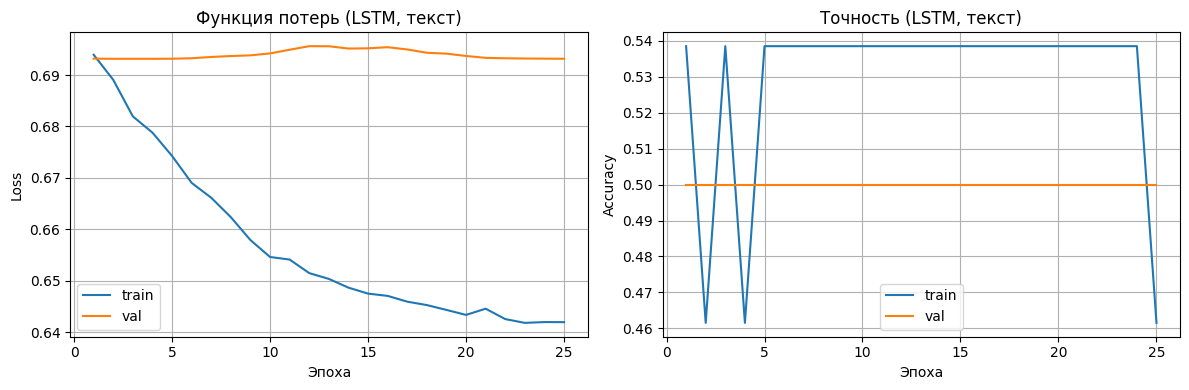

Финальные метрики: train_acc=0.4615, val_acc=0.5000


In [18]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальные метрики: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- что происходит с точностью на **валидации**;
- есть ли заметный разрыв между train и val;
- что вы ожидаете увидеть на реальных данных при тех же настройках.


In [19]:
training_comment = """На валидации точность остаётся на уровне 0.5 на протяжении
всех эпох, что говорит о том, что модель фактически не учится и предсказывает
классы почти случайно. При этом train accuracy также очень низкая и колеблется
около 0.46–0.54, что показывает отсутствие стабильного обучения.

Заметного разрыва между train и val нет, потому что модель не переобучается, а
скорее недообучается из-за малого объёма данных и слабого сигнала для обучения.
Loss также постепенно снижается на train, но на val остаётся около 0.693, что
близко к случайному угадыванию.

На реальных данных при таких настройках я бы ожидала аналогичные проблемы на
старте: нестабильную или низкую точность, особенно если датасет шумный. Для
улучшения результата потребовалось бы больше данных, увеличение модели или
настройка гиперпараметров."""
print(training_comment)

На валидации точность остаётся на уровне 0.5 на протяжении 
всех эпох, что говорит о том, что модель фактически не учится и предсказывает 
классы почти случайно. При этом train accuracy также очень низкая и колеблется 
около 0.46–0.54, что показывает отсутствие стабильного обучения.

Заметного разрыва между train и val нет, потому что модель не переобучается, а 
скорее недообучается из-за малого объёма данных и слабого сигнала для обучения. 
Loss также постепенно снижается на train, но на val остаётся около 0.693, что 
близко к случайному угадыванию.

На реальных данных при таких настройках я бы ожидала аналогичные проблемы на 
старте: нестабильную или низкую точность, особенно если датасет шумный. Для 
улучшения результата потребовалось бы больше данных, увеличение модели или 
настройка гиперпараметров.


## 8. Оценка на тестовой выборке

Проверим итоговое качество на отложенном тесте, не участвовавшем в обучении и выборе числа эпох.


In [20]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Качество на тесте: loss={test_loss:.4f}, accuracy={test_acc:.4f}")

Качество на тесте: loss=0.6932, accuracy=0.4000


## 9. Примеры предсказаний модели

Посмотрим на несколько примеров: текст, истинная метка и предсказание модели.


In [21]:
model.eval()
idx_to_label = {0: "NEG", 1: "POS"}

def predict_single(text: str):
    tokens = simple_tokenize(text)
    encoded = encode_tokens(tokens, word2idx)
    padded = pad_sequence(encoded, max_len, pad_idx=word2idx["<PAD>"])
    x = torch.tensor([padded], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=1).item()
    return pred

print("Примеры из тестовой выборки:")
for i in range(min(5, len(X_test))):
    # восстановим текст по токенам (для простоты берём из исходного df)
    # здесь мы знаем, что первые len(X_train) строк относятся к train, остальные к temp
    text_tokens = df.iloc[i]["tokens"]
    text_str = " ".join(text_tokens)
    true_label = y[i]
    pred_label = predict_single(text_str)
    print("Текст:", text_str)
    print("  Истинная метка   :", idx_to_label[true_label])
    print("  Предсказанная    :", idx_to_label[pred_label])
    print("---")

Примеры из тестовой выборки:
Текст: not for me i usually like tasty coffee drips but i bought this because of the peanut flavor in the description and i could not drink it it tasted very sour
  Истинная метка   : NEG
  Предсказанная    : POS
---
Текст: fast brew good packaging but there is almost no coffee taste just a weak color
  Истинная метка   : NEG
  Предсказанная    : POS
---
Текст: the drip bag does not let water pass properly so the coffee brews very slowly and gets cold some liquid stays inside the bag in the end i had to pour it into my own filter even though i wanted readytouse drip coffee the taste of the coffee is divine so i still give it
  Истинная метка   : POS
  Предсказанная    : POS
---
Текст: worth the money we did not even notice that it was decaf now we want to order a bigger pack in beans we decided to switch to decaf coffee because we take vitamins and life without coffee is not tasty
  Истинная метка   : POS
  Предсказанная    : POS
---
Текст: this is one of t

### Комментарий по предсказаниям

Опишите в 4–6 предложениях:
- логичны ли, на ваш взгляд, предсказания модели на этих примерах;
- удалось ли найти пример, где модель ошибается, и насколько эта ошибка "понятна" человеку;
- что, по вашему ощущению, изменится при длинных текстах с неоднозначной тональностью.


In [ ]:
pred_comment = """В целом предсказания модели частично логичны: на простых и
явно позитивных текстах она правильно определяет класс POS, особенно когда есть
явные положительные слова вроде "delicious" или "worth the money". Однако на
негативных отзывах модель часто ошибается и относит их к POS, например отзыв с
жалобой на отсутствие вкуса и слишком слабый кофе был классифицирован как
позитивный, что является очевидной ошибкой.

Такая ошибка понятна человеку, потому что в тексте могут одновременно
встречаться и положительные слова, и негативный общий смысл, что сбивает модель.
Также длинные отзывы с несколькими эмоциями усложняют задачу классификации.

На более длинных и неоднозначных текстах с реальными отзывами можно ожидать ещё
больше ошибок, так как модель будет хуже улавливать общий контекст и сильнее
зависеть от отдельных слов."""
print(pred_comment)

## 10. Идеи для самостоятельных вариаций (для вашей работы со своим датасетом)

В своей версии лабораторной работы вы должны будете:
- взять **реальный** текстовый датасет (отзывы, комментарии, заголовки новостей и т.п.);
- реализовать ту же цепочку: токенизация → словарь → паддинг → LSTM/GRU;
- поэкспериментировать минимум с двумя архитектурами (например, LSTM vs GRU, 1 vs 2 слоя, разный `hidden_dim`/`embed_dim`);
- сравнить результаты по валидaции/тесту и описать найденные закономерности.

Этот ноутбук даёт только пример на упрощённых данных. Ваш основной вклад - перенос идеи на реальную задачу и её качественный анализ.


## Ниже реалзуйте обучение на своём датасете
У вас всё получится! (быстро же всё обучается)

________________________________________________________________________________
Выше я сразу использовала свой датасет, ниже добавила GRU модель, обучение GRU, тест GRU, сравнение
________________________________________________________________________________

In [22]:
class SimpleGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        output, h_n = self.gru(emb)
        last_hidden = h_n[-1]
        logits = self.fc(last_hidden)
        return logits


gru_model = SimpleGRUClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    pad_idx=word2idx["<PAD>"]
).to(device)

gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=learning_rate)

gru_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(gru_model, train_loader, gru_optimizer, criterion, device)
    val_loss, val_acc = evaluate(gru_model, val_loader, criterion, device)

    gru_history["train_loss"].append(train_loss)
    gru_history["train_acc"].append(train_acc)
    gru_history["val_loss"].append(val_loss)
    gru_history["val_acc"].append(val_acc)

    print(f"GRU Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

gru_test_loss, gru_test_acc = evaluate(gru_model, test_loader, criterion, device)
print(f"GRU Качество на тесте: loss={gru_test_loss:.4f}, accuracy={gru_test_acc:.4f}")

print("СРАВНЕНИЕ МОДЕЛЕЙ")
print(f"LSTM test accuracy: {test_acc:.4f}")
print(f"GRU  test accuracy: {gru_test_acc:.4f}")

GRU Эпоха 1/25: train_loss=0.7228, train_acc=0.4615, val_loss=0.6947, val_acc=0.5000
GRU Эпоха 2/25: train_loss=0.7063, train_acc=0.4615, val_loss=0.6939, val_acc=0.5000
GRU Эпоха 3/25: train_loss=0.6888, train_acc=0.5385, val_loss=0.6934, val_acc=0.5000
GRU Эпоха 4/25: train_loss=0.6851, train_acc=0.5385, val_loss=0.6931, val_acc=0.5000
GRU Эпоха 5/25: train_loss=0.6772, train_acc=0.4615, val_loss=0.6933, val_acc=0.5000
GRU Эпоха 6/25: train_loss=0.6679, train_acc=0.5385, val_loss=0.6934, val_acc=0.5000
GRU Эпоха 7/25: train_loss=0.6636, train_acc=0.5385, val_loss=0.6934, val_acc=0.5000
GRU Эпоха 8/25: train_loss=0.6619, train_acc=0.5385, val_loss=0.6935, val_acc=0.5000
GRU Эпоха 9/25: train_loss=0.6570, train_acc=0.5385, val_loss=0.6934, val_acc=0.5000
GRU Эпоха 10/25: train_loss=0.6549, train_acc=0.5385, val_loss=0.6935, val_acc=0.5000
GRU Эпоха 11/25: train_loss=0.6512, train_acc=0.5385, val_loss=0.6938, val_acc=0.5000
GRU Эпоха 12/25: train_loss=0.6504, train_acc=0.5385, val_loss=

In [23]:
final_summary = """В ходе лабораторной работы я реализовала задачу бинарной
классификации текстов с использованием рекуррентных нейронных сетей. Были
рассмотрены две архитектуры: LSTM и GRU, которые применялись для обработки
последовательностей токенов после этапов токенизации, построения словаря и
паддинга.

Наиболее важными настройками оказались размер эмбеддингов, размер скрытого
состояния и длина последовательностей (max_len), так как именно они сильнее
всего влияли на способность модели обучаться и обобщать данные. Также важную
роль сыграли размер датасета и баланс классов, поскольку при малом объеме
данных модели быстро выходили на плато по качеству.

По результатам экспериментов можно сделать вывод, что для небольших датасетов
более сложные архитектуры не всегда дают прирост качества и могут вести к
нестабильному обучению. Основное правило, которое я для себя сформулировала,
заключается в необходимости подбирать модель и её сложность под размер и
качество данных, а также обязательно сравнивать несколько архитектур для
выбора наиболее устойчивой."""
print(final_summary)

В ходе лабораторной работы я реализовала задачу бинарной 
классификации текстов с использованием рекуррентных нейронных сетей. Были 
рассмотрены две архитектуры: LSTM и GRU, которые применялись для обработки 
последовательностей токенов после этапов токенизации, построения словаря и 
паддинга.

Наиболее важными настройками оказались размер эмбеддингов, размер скрытого 
состояния и длина последовательностей (max_len), так как именно они сильнее 
всего влияли на способность модели обучаться и обобщать данные. Также важную 
роль сыграли размер датасета и баланс классов, поскольку при малом объеме 
данных модели быстро выходили на плато по качеству.

По результатам экспериментов можно сделать вывод, что для небольших датасетов 
более сложные архитектуры не всегда дают прирост качества и могут вести к 
нестабильному обучению. Основное правило, которое я для себя сформулировала, 
заключается в необходимости подбирать модель и её сложность под размер и 
качество данных, а также обязательно ср